# **Setup**

In [ ]:
!uv add relbench torch torch_geometric pandas tqdm matplotlib seaborn torch -q

In [2]:
from relbench.datasets import get_dataset

dataset = get_dataset(name="rel-hm", download=True)
db = dataset.get_db()

Loading Database object from /home/dimitrius/.cache/relbench/rel-hm/db...
Done in 2.18 seconds.


In [3]:
tables = list(db.table_dict.keys())
print(f"Available tables: {tables}")

Available tables: ['article', 'transactions', 'customer']


In [4]:
transactions = db.table_dict["transactions"].df

print(f"Total transactions: {len(transactions)}\n")
transactions.head()

Total transactions: 15187287



,t_dat,customer_id,article_id,price,sales_channel_id
0,2019-09-07,155,51985,0.010153,1
1,2019-09-07,155,51985,0.010153,1
2,2019-09-07,155,83127,0.042356,1
3,2019-09-07,155,6066,0.005068,1
4,2019-09-07,155,78525,0.033881,1


In [5]:
transactions.isna().any()

t_dat               False
customer_id         False
article_id          False
price               False
sales_channel_id    False
dtype: bool

In [6]:
from pandas import to_datetime

transactions["date"] = to_datetime(transactions["t_dat"])
transactions["basket_id"] = transactions.groupby(["customer_id", "date"]).ngroup()

baskets = (
    transactions.groupby("basket_id", group_keys=False)["article_id"]
    .apply(list)
    .reset_index(drop=True)
)

In [7]:
baskets = baskets[baskets.apply(len) >= 2].reset_index(drop=True)
print(f"Number of baskets with 2+ items: {len(baskets)}")

Number of baskets with 2+ items: 3125281


In [8]:
from collections import Counter
from tqdm import tqdm
from itertools import combinations

copurchase_counts = Counter()

for items in tqdm(baskets.values):
    for item1, item2 in combinations(items, 2):
        copurchase_counts[(item1, item2)] += 1

100%|██████████| 3125281/3125281 [00:40<00:00, 77634.36it/s]


In [9]:
list(copurchase_counts.items())[:5]

[((np.int64(79278), np.int64(79278)), 53),
 ((np.int64(49478), np.int64(76590)), 1),
 ((np.int64(49478), np.int64(83622)), 1),
 ((np.int64(76590), np.int64(83622)), 1),
 ((np.int64(90060), np.int64(99926)), 6)]

In [10]:
len(copurchase_counts)

21881859

In [11]:
filtered_copurchase_counts = {
    items: times for items, times in copurchase_counts.items() if times >= 2
}

In [12]:
print(len(filtered_copurchase_counts))
list(filtered_copurchase_counts.items())[:5]

6979389


[((np.int64(79278), np.int64(79278)), 53),
 ((np.int64(90060), np.int64(99926)), 6),
 ((np.int64(90060), np.int64(78719)), 5),
 ((np.int64(90060), np.int64(93744)), 15),
 ((np.int64(99926), np.int64(93744)), 5)]

In [13]:
unique_items = {
    item for item_tuple in filtered_copurchase_counts.keys() for item in item_tuple
}
len(unique_items)

58929

In [14]:
articles = db.table_dict["article"].df

print(articles.columns)
articles.head(5)

Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc'],
      dtype='object')


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,0,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,1,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,2,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,3,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,4,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [15]:
articles.drop(
    columns=[
        "product_code",
        "product_type_name",
        "product_group_name",
        "graphical_appearance_name",
        "colour_group_name",
        "perceived_colour_value_id",
        "perceived_colour_value_name",
        "perceived_colour_master_id",
        "perceived_colour_master_name",
        "department_name",
        "index_name",
        "index_group_name",
        "section_name",
        "garment_group_name",
        "detail_desc",
    ],
    inplace=True,
)

In [16]:
from sklearn.preprocessing import LabelEncoder

df_encoded = articles.copy()
label_encoder = LabelEncoder()

for col in df_encoded.select_dtypes(include=["object", "category"]).columns:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col].astype(str))

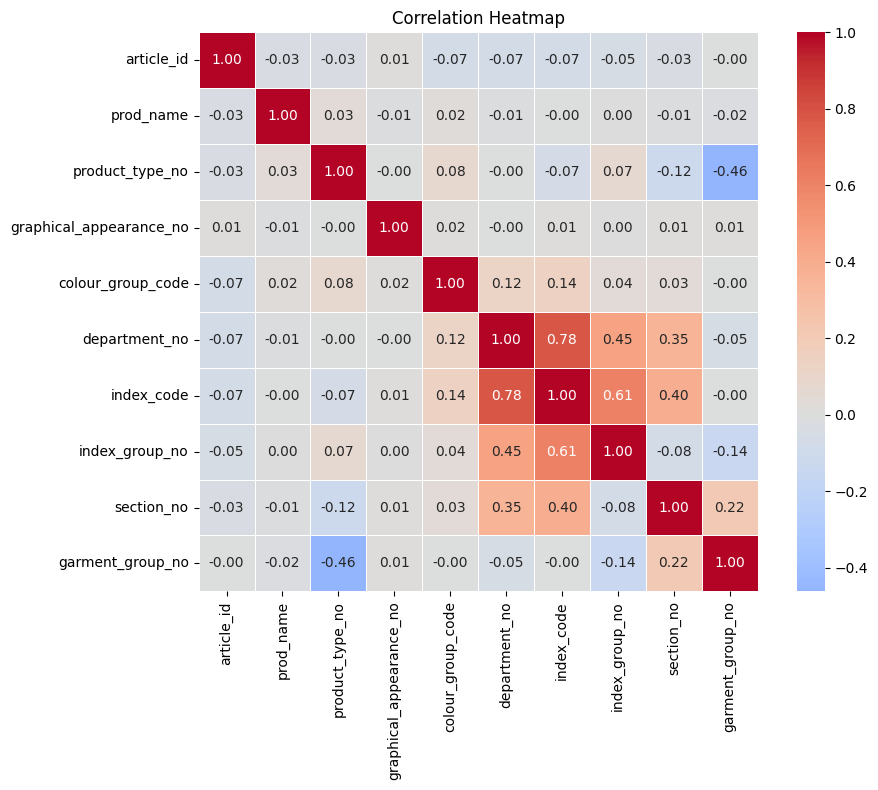

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    square=True,
    linewidths=0.5,
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [18]:
articles.drop(columns=["department_no"], inplace=True)

In [19]:
articles.isna().any()

article_id                 False
prod_name                  False
product_type_no            False
graphical_appearance_no    False
colour_group_code          False
index_code                 False
index_group_no             False
section_no                 False
garment_group_no           False
dtype: bool

# **Data Graph format transformation**

In [20]:
items_in_articles = articles[articles["article_id"].isin(unique_items)]
print(f"Items with metadata: {len(items_in_articles)}/{len(unique_items)}")

Items with metadata: 58929/58929


In [21]:
num_nodes = len(unique_items)

unique_items_sorted = sorted(list(unique_items))
item_to_idx = {item_id: idx for idx, item_id in enumerate(unique_items_sorted)}

In [22]:
articles_df_filtered = df_encoded[
    df_encoded["article_id"].isin(unique_items_sorted)
].copy()

articles_df_filtered = articles_df_filtered.sort_values("article_id").reset_index(
    drop=True
)

In [23]:
import torch

feature_cols = articles_df_filtered.drop(columns=["article_id"]).columns
x = torch.tensor(articles_df_filtered[feature_cols].values, dtype=torch.float)

print(f"Number of nodes: {num_nodes}")
print(f"Node feature matrix shape: {x.shape}")

Number of nodes: 58929
Node feature matrix shape: torch.Size([58929, 9])


In [24]:
edge_list = list(filtered_copurchase_counts.keys())
weight_list = list(filtered_copurchase_counts.values())

In [25]:
train_edges = edge_list[: int(0.7 * len(edge_list))]
train_weights = weight_list[: int(0.7 * len(weight_list))]

val_edges = edge_list[int(0.7 * len(edge_list)) : int(0.8 * len(edge_list))]
val_weights = weight_list[int(0.7 * len(weight_list)) : int(0.8 * len(weight_list))]

test_edges = edge_list[int(0.8 * len(edge_list)) :]
test_weights = weight_list[int(0.8 * len(weight_list)) :]

In [26]:
train_edge_index = torch.tensor(
    [
        [item_to_idx[e[0]] for e in train_edges]
        + [item_to_idx[e[1]] for e in train_edges],
        [item_to_idx[e[1]] for e in train_edges]
        + [item_to_idx[e[0]] for e in train_edges],
    ],
    dtype=torch.long,
)

val_edge_index = torch.tensor(
    [[item_to_idx[e[0]] for e in val_edges], [item_to_idx[e[1]] for e in val_edges]],
    dtype=torch.long,
)

test_edge_index = torch.tensor(
    [[item_to_idx[e[0]] for e in test_edges], [item_to_idx[e[1]] for e in test_edges]],
    dtype=torch.long,
)

In [27]:
print(f"Train edges: {len(train_edges)}")
print(f"Val edges: {len(val_edges)}")
print(f"Test edges: {len(test_edges)}")

Train edges: 4885572
Val edges: 697939
Test edges: 1395878


In [28]:
from torch_geometric.data import Data

data = Data(x=x, edge_index=train_edge_index, edge_weight=train_weights)

data.num_nodes = num_nodes
data.val_edges = val_edge_index
data.test_edges = test_edge_index

print(f"{data}\n")
print(f"Validation edges: {data.val_edges.shape}")
print(f"Test edges: {data.test_edges.shape}")

/home/dimitrius/Projects/IIS - Consumer Purchases/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(x=[58929, 9], edge_index=[2, 9771144], edge_weight=[4885572], num_nodes=58929, val_edges=[2, 697939], test_edges=[2, 1395878])

Validation edges: torch.Size([2, 697939])
Test edges: torch.Size([2, 1395878])


In [29]:
import os
import torch

output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

file_path = os.path.join(output_dir, "data.pt")
torch.save(data, file_path)

print(f"Data saved to {file_path}")

Data saved to output/data.pt
